In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Raw data 19-06-2026 00:00 to 22-06-2026 23:59 = 4 days.

Informe de Inicio, Parada e Inactividad 18-06-2026 19:00 to 22-06-2026 18:59 = 4 days.
 
Reporte de actividades 18-06-2026 19:00 to 22-06-2026 18:59 = 4 days.

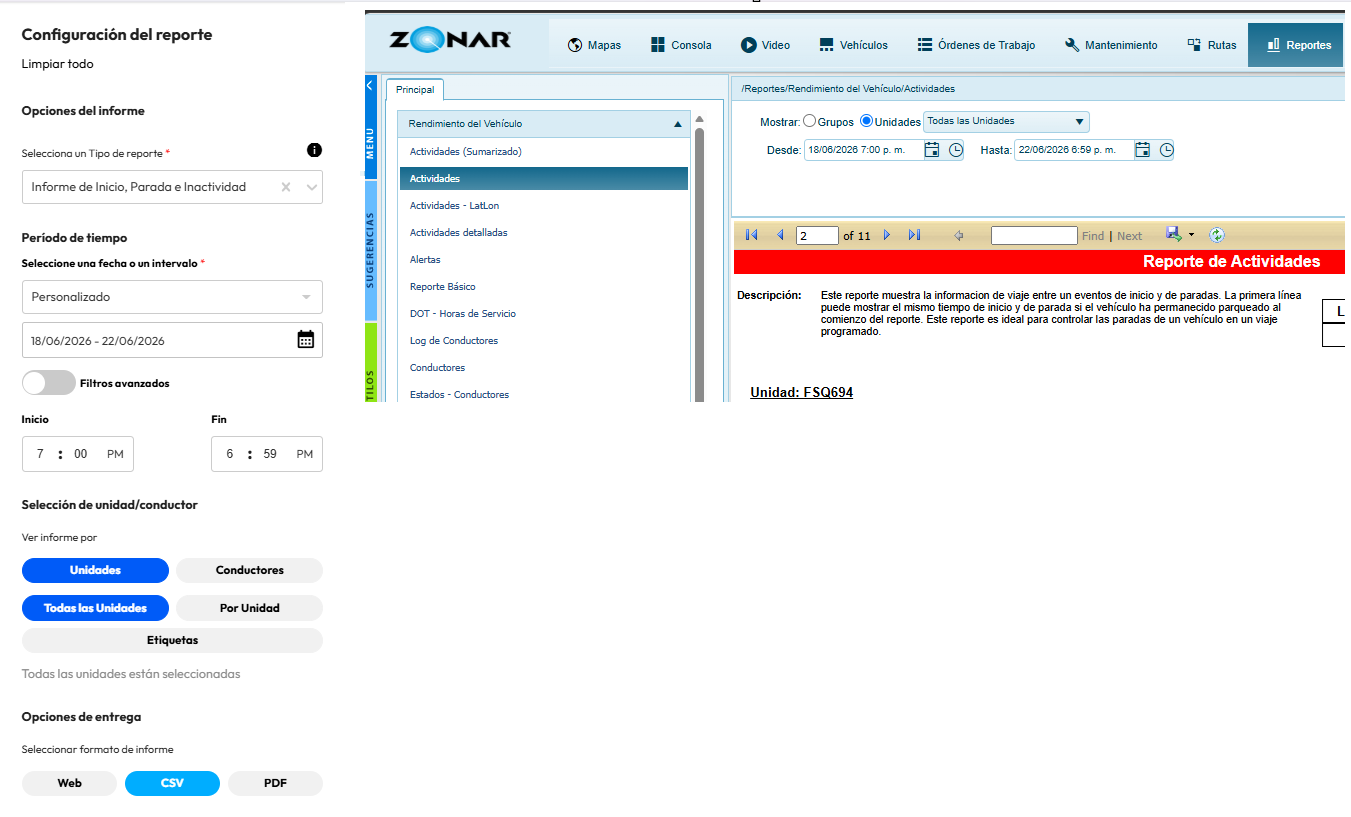

Analysis result:

In [33]:
result={'Unit':['Ignition','TSO','CRM'],
        'fsq694':[208.20,83.01,83.050]
}

print(result)

{'Unit': ['Ignition', 'TSO', 'CRM'], 'fsq694': [208.2, 83.01, 83.05]}


Informe de Inicio, Parada e Inactividad 18-06-2026 19:00 to 22-06-2026 18:59 = 4 days.

In [34]:
ipi=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\ipi1822_0626.csv',sep=',') 
ipi.info()

<class 'pandas.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unidad               554 non-null    str    
 1   Conductor            554 non-null    str    
 2   Evento               554 non-null    str    
 3   Dirección            554 non-null    str    
 4   Fecha                554 non-null    str    
 5   Tiempo (UTC-5)       554 non-null    str    
 6   Duración del Evento  554 non-null    str    
 7   Distancia (km)       554 non-null    float64
dtypes: float64(1), str(7)
memory usage: 34.8 KB


In [35]:
ipi_filtered=ipi[['Unidad','Distancia (km)']]
ipi_filtered.groupby('Unidad').sum()

,Distancia (km)
Unidad,
FSQ694,208.20
KYR910,417.93
NOX568,450.34


Reporte de actividades 12-06-2026 18-06-2026 19:00 to 22-06-2026 18:59 = 4 days.

In [36]:
ar=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Activity Report_v3_es_1822_0626.csv',sep=',')
ar['MilesDriven_float']=0.0
aux='s'
ar.info()
cad_str_to_float=[]

for i in range(0,ar.shape[0]):
    try:
        aux=ar.iloc[i,4].replace('.','')
        ar.iloc[i,4]=aux
        aux=ar.iloc[i,4].replace(',','.')
        cad_str_to_float.append(float(aux))
    except AttributeError as e:
        print("Error found on: ",ar.iloc[i,2],ar.iloc[i,1])
        cad_str_to_float.append(0.0)

ar['MilesDriven_float']=cad_str_to_float

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GroupName          0 non-null      float64
 1   UnitName           366 non-null    str    
 2   StartTime          366 non-null    str    
 3   MovingTimeSecs     366 non-null    str    
 4   MilesDriven        366 non-null    str    
 5   MaxSpeed           366 non-null    int64  
 6   StopTime           366 non-null    str    
 7   textbox43          366 non-null    str    
 8   StopLengthSecs     366 non-null    str    
 9   ContactName        366 non-null    str    
 10  textbox28          366 non-null    str    
 11  textbox29          366 non-null    str    
 12  textbox30          366 non-null    int64  
 13  textbox32          366 non-null    str    
 14  MovingTimeSecs_1   366 non-null    str    
 15  MilesDriven_1      366 non-null    str    
 16  MaxSpeed_1         366 non-null    in

In [37]:
ar_filtered=ar[['UnitName','MilesDriven_float']]
ar_filtered.info()
ar_filtered.groupby('UnitName').sum()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UnitName           366 non-null    str    
 1   MilesDriven_float  366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


,MilesDriven_float
UnitName,
Unidad: FSQ694,83.01
Unidad: KYR910,171.15
Unidad: NOX568,202.82


Analysis by unit.

FSQ694

Informe de Inicio, Parada e Inactividad 18-06-2026 19:00 to 22-06-2026 18:59 = 4 days.

In [38]:
ipi_fsq694=ipi[ipi['Unidad'].str.contains('FSQ694')]
ipi_fsq694['Distancia (km)'].sum()

np.float64(208.2)

Raw data 19-06-2026 00:00 to 22-06-2026 23:59 = 4 days.

In [39]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\fsq694_1922_0626.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  519 non-null    str  
 1   Message  519 non-null    str  
 2   Status   519 non-null    str  
dtypes: str(3)
memory usage: 12.3 KB


In [40]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

83050


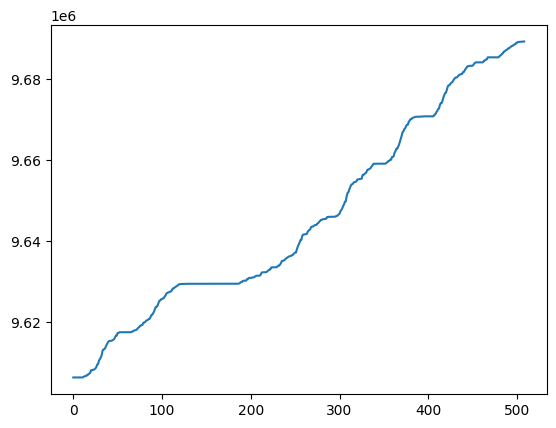

In [41]:
y_axis=[]
x_axis=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(0,len(odometer)):
    #print(date[i],' -> ',x_axis[i],y_axis[i],raw[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)